In [8]:
"""Correlations between Variables"""

'Correlations between Variables'

Optimales Lambda (Alpha): 1.2706249433421697

Variablen mit echtem Einfluss (Lasso-Selektion):
                      Variable    Gewicht
3                Seller Rating  28.556265
4  zahl der verkauften artikel  12.954047
2                    Verfugbar   5.861827
0              Batteriezustand   5.656077
1                     verkauft -22.241046


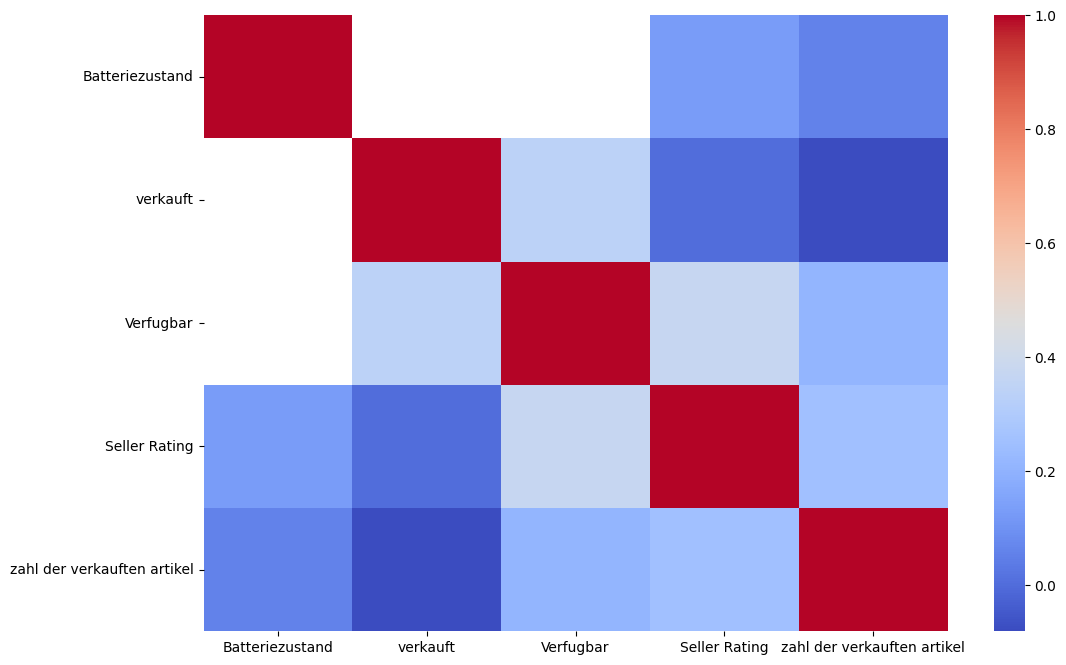

In [9]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer # Neu hinzugefügt für NaN-Werte

# 1. Daten laden
file_path = os.path.expanduser("~/Desktop/regge.xlsx")
df = pd.read_excel(file_path)

# 2. Datenbereinigung (Pre-processing)
# Preis säubern: 'EUR 709,00' -> 709.0
df['Preis'] = df['Preis'].astype(str).str.replace(r'[^\d,]', '', regex=True).str.replace(',', '.', regex=False)
df['Preis'] = pd.to_numeric(df['Preis'], errors='coerce')

# Spezialfunktion für '10+', '99.9%' etc.
def clean_mixed_column(col_series):
    return pd.to_numeric(col_series.astype(str).str.extract(r'(\d+)')[0], errors='coerce')

# Numerische Spalten säubern (Lassen NaN erst mal stehen für den Imputer)
numeric_cols_to_fix = ['Verfugbar', 'Batteriezustar', 'Seller Rating', 'zahl der verkaufter']
for col in numeric_cols_to_fix:
    if col in df.columns:
        df[col] = clean_mixed_column(df[col])

# 3. Kategoriale Variablen umwandeln
categorical_cols = ['Zustand', 'Farbe', 'Herkunftsland', 'Verkaufsart', 'Seller Type']
df_final = pd.get_dummies(df, columns=[c for c in categorical_cols if c in df.columns], drop_first=True)

# 4. Variablen für die Regression definieren
X = df_final.drop(columns=['Preis', 'Shop/Seller', 'URL'], errors='ignore')
X = X.select_dtypes(include=['number'])
y = df_final['Preis']

# 5. NaN-Werte behandeln (IMPUTER)
# Wir füllen Lücken in X mit dem Median der jeweiligen Spalte
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

# Zeilen mit fehlendem Preis (y) müssen wir komplett löschen
mask = ~y.isna()
X_imputed = X_imputed[mask]
y = y[mask]

# 6. Skalierung & Lasso Regression
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# LassoCV führt die automatische Modellwahl durch
lasso = LassoCV(cv=5, random_state=42).fit(X_scaled, y)

# 7. Ergebnisse anzeigen
coef_results = pd.DataFrame({'Variable': X.columns, 'Gewicht': lasso.coef_})
significant_features = coef_results[coef_results['Gewicht'] != 0].sort_values(by='Gewicht', ascending=False)

print(f"Optimales Lambda (Alpha): {lasso.alpha_}")
print("\nVariablen mit echtem Einfluss (Lasso-Selektion):")
print(significant_features)

# Korrelationsmatrix
plt.figure(figsize=(12, 8))
sns.heatmap(X.corr(), cmap='coolwarm', annot=False)
plt.show()

In [10]:
"""
Was ist mit den anderen Variablen passiert?
Alles, was nicht in deiner Liste auftaucht (z. B. bestimmte Farben oder Herkunftsländer), wurde von Lasso auf 0 gesetzt.
Das bedeutet für dein "Modell C"-Problem: Diese Variablen erklären „nur ein bisschen“ mehr, erhöhen aber die Komplexität zu stark. Lasso sagt dir: „Ignoriere die Farbe für die Preisvorhersage, sie ist statistisches Rauschen.“


Das ist tatsächlich ein sehr spannendes Ergebnis! In der Theorie würde man erwarten, dass der technische Zustand (Batterie) den Preis bestimmt, aber deine Daten zeigen die Realität des Online-Handels:
Warum das Seller Rating wichtiger ist als die Batterie:
Risiko-Aversion: Bei gebrauchten Smartphones für 700€+ haben Käufer Angst vor Betrug oder versteckten Mängeln. Ein Verkäufer mit 100% Rating ist eine "Versicherung". Dafür zahlen Leute einen Aufpreis, egal ob die Batterie bei 95% oder 100% liegt.
Händler-Effekt: Top-Ratings gehören oft zu gewerblichen Refurbished-Händlern (wie rebuy oder asgoodasnew). Diese bieten Garantie und Rückgaberecht an – Dinge, die den Preis massiv heben, aber nichts mit der Hardware zu tun haben.
Wahrnehmung: Der Batteriezustand ist oft eine Angabe des Verkäufers, der man glauben muss oder nicht. Das Rating hingegen ist eine "objektive" Statistik der gesamten eBay-Community.
Was bedeutet das für dein "Modell B"?
Dein Modell hat erfolgreich die psychologischen Faktoren (Vertrauen = Preis) von den physischen Faktoren (Technik) getrennt.
"""

'\nWas ist mit den anderen Variablen passiert?\nAlles, was nicht in deiner Liste auftaucht (z. B. bestimmte Farben oder Herkunftsländer), wurde von Lasso auf 0 gesetzt.\nDas bedeutet für dein "Modell C"-Problem: Diese Variablen erklären „nur ein bisschen“ mehr, erhöhen aber die Komplexität zu stark. Lasso sagt dir: „Ignoriere die Farbe für die Preisvorhersage, sie ist statistisches Rauschen.“\n\n\nDas ist tatsächlich ein sehr spannendes Ergebnis! In der Theorie würde man erwarten, dass der technische Zustand (Batterie) den Preis bestimmt, aber deine Daten zeigen die Realität des Online-Handels:\nWarum das Seller Rating wichtiger ist als die Batterie:\nRisiko-Aversion: Bei gebrauchten Smartphones für 700€+ haben Käufer Angst vor Betrug oder versteckten Mängeln. Ein Verkäufer mit 100% Rating ist eine "Versicherung". Dafür zahlen Leute einen Aufpreis, egal ob die Batterie bei 95% oder 100% liegt.\nHändler-Effekt: Top-Ratings gehören oft zu gewerblichen Refurbished-Händlern (wie rebuy oder

In [23]:
import pandas as pd
import os
import statsmodels.api as sm
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# 1. Daten laden
file_path = os.path.expanduser("~/Desktop/regge.xlsx")
df = pd.read_excel(file_path)

# 2. Datenbereinigung (PREIS)
# WICHTIG: Wir stellen sicher, dass es eine Series bleibt
preis_raw = df['Preis'].astype(str).str.replace(r'[^\d,]', '', regex=True).str.replace(',', '.', regex=False)
df['Preis'] = pd.to_numeric(preis_raw, errors='coerce')

# Spezialfunktion für '10+', '99.9%' etc.
def clean_mixed_column(col_series):
    # .squeeze() stellt sicher, dass wir ein 1D-Objekt haben
    extracted = col_series.astype(str).str.extract(r'(\d+)')
    return pd.to_numeric(extracted.iloc[:, 0], errors='coerce')

# Numerische Spalten säubern
numeric_cols = ['Verfugbar', 'Batteriezustar', 'Seller Rating', 'zahl der verkaufter']
for col in numeric_cols:
    if col in df.columns:
        df[col] = clean_mixed_column(df[col])

# 3. Kategoriale Variablen (Text zu 0/1)
categorical_cols = ['Zustand', 'Farbe', 'Herkunftsland', 'Verkaufsart', 'Seller Type']
df_final = pd.get_dummies(df, columns=[c for c in categorical_cols if c in df.columns], drop_first=True)

# 4. X und y definieren & Synchronisieren
X = df_final.drop(columns=['Preis', 'Shop/Seller', 'URL'], errors='ignore').select_dtypes(include=['number'])
y = df_final['Preis']

# Maske für Zeilen mit existierendem Preis
mask = y.notna()
X = X[mask]
y = y[mask]

# 5. Fehlende Werte füllen
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)
X_final = pd.DataFrame(X_imputed, columns=X.columns)

# 6. LASSO
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_final)
lasso = LassoCV(cv=5, random_state=42).fit(X_scaled, y)

# 7. OLS
X_with_constant = sm.add_constant(X_final)
ols_model = sm.OLS(y.values, X_with_constant).fit()

# 8. Ergebnisse
print(f"Erfolgreich: {len(X_final)} Datensätze analysiert.")
print("\n--- LASSO (Wichtigste Variablen) ---")
coef_results = pd.DataFrame({'Variable': X.columns, 'Gewicht': lasso.coef_})
print(coef_results[coef_results['Gewicht'] != 0].sort_values(by='Gewicht', ascending=False))

print("\n--- OLS SUMMARY ---")
print(ols_model.summary())

Erfolgreich: 201 Datensätze analysiert.

--- LASSO (Wichtigste Variablen) ---
                      Variable    Gewicht
3                Seller Rating  28.556265
4  zahl der verkauften artikel  12.954047
2                    Verfugbar   5.861827
0              Batteriezustand   5.656077
1                     verkauft -22.241046

--- OLS SUMMARY ---
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.258
Model:                            OLS   Adj. R-squared:                  0.239
Method:                 Least Squares   F-statistic:                     13.55
Date:                Fri, 08 May 2026   Prob (F-statistic):           2.38e-11
Time:                        16:03:39   Log-Likelihood:                -1155.2
No. Observations:                 201   AIC:                             2322.
Df Residuals:                     195   BIC:                             2342.
Df Model:        

In [24]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Funktion zur Berechnung des VIF
def calculate_vif(X_df):
    vif_data = pd.DataFrame()
    vif_data["Variable"] = X_df.columns
    # Wir berechnen den VIF für jede Spalte i
    vif_data["VIF"] = [variance_inflation_factor(X_df.values, i) for i in range(len(X_df.columns))]
    return vif_data.sort_values(by="VIF", ascending=False)

# 2. VIF berechnen (wir nutzen X_final ohne die Konstante)
vif_results = calculate_vif(X_final)

print("\n--- MULTIKOLINEARITÄTS-CHECK (VIF) ---")
print(vif_results)



--- MULTIKOLINEARITÄTS-CHECK (VIF) ---
                      Variable       VIF
2                    Verfugbar  3.957300
0              Batteriezustand  3.596122
3                Seller Rating  2.266031
4  zahl der verkauften artikel  1.218448
1                     verkauft  1.214422


In [25]:
#Ein letzter Tipp: Da die VIF-Werte nun sauber sind, kannst du den p-Werten der OLS-Summary für diese 5 Variablen jetzt voll vertrauen.

In [28]:
import pandas as pd
import os
import statsmodels.api as sm
from sklearn.impute import SimpleImputer

# 1. Daten laden
file_path = os.path.expanduser("~/Desktop/regge.xlsx")
df = pd.read_excel(file_path)
df.columns = df.columns.str.strip()

# 2. Preis-Reinigung (Sicherstellen, dass es 1D ist)
preis_series = df['Preis'].astype(str).str.replace(r'[^\d,]', '', regex=True).str.replace(',', '.', regex=False)
df['Preis'] = pd.to_numeric(preis_series, errors='coerce')

# 3. Korrigierte Funktion für '10+', '99.9%' etc.
def clean_mixed(col_series):
    # .extract() liefert DF -> .iloc[:, 0] macht daraus eine Series (1D)
    extracted = col_series.astype(str).str.extract(r'(\d+)')
    return pd.to_numeric(extracted.iloc[:, 0], errors='coerce')

# Spalten säubern
relevant_cols = ['Verfugbar', 'Batteriezustand', 'Seller Rating', 'verkauft', 'zahl der verkauften artikel']
for col in relevant_cols:
    if col in df.columns:
        df[col] = clean_mixed(df[col])

# 4. Fusion der Sales-Variablen
s1 = df['zahl der verkauften artikel'].fillna(0) if 'zahl der verkauften artikel' in df.columns else 0
s2 = df['verkauft'].fillna(0) if 'verkauft' in df.columns else 0
df['Total_Sales_Performance'] = s1 + s2

# 5. Auswahl & Synchronisation
features = ['Seller Rating', 'Total_Sales_Performance', 'Verfugbar', 'Batteriezustand']
X = df[[f for f in features if f in df.columns]]
y = df['Preis']

mask = y.notna()
X = X[mask]
y = y[mask]

# 6. Imputing & OLS
imputer = SimpleImputer(strategy='median')
X_final = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

X_with_const = sm.add_constant(X_final)
ols_model = sm.OLS(y.values, X_with_const).fit()

# 7. Output
print(f"Modell erfolgreich berechnet ({len(X_final)} Zeilen).")
print(f"R²: {ols_model.rsquared:.4f}")
print(ols_model.summary())

Modell erfolgreich berechnet (201 Zeilen).
R²: 0.1882
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.188
Model:                            OLS   Adj. R-squared:                  0.172
Method:                 Least Squares   F-statistic:                     11.36
Date:                Fri, 08 May 2026   Prob (F-statistic):           2.60e-08
Time:                        16:11:44   Log-Likelihood:                -1164.3
No. Observations:                 201   AIC:                             2339.
Df Residuals:                     196   BIC:                             2355.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------

In [29]:
skalierte Werte

SyntaxError: invalid syntax (169834368.py, line 1)

In [30]:
from sklearn.preprocessing import StandardScaler

# 1. Skalierung der Prädiktoren
scaler = StandardScaler()
# Wir skalieren nur X_final (unsere 4 Hauptvariablen)
X_scaled_array = scaler.fit_transform(X_final)
X_scaled = pd.DataFrame(X_scaled_array, columns=X_final.columns)

# 2. OLS mit skalierten Daten (Konstante nicht vergessen!)
X_scaled_with_const = sm.add_constant(X_scaled)
ols_scaled_model = sm.OLS(y.values, X_scaled_with_const).fit()

# 3. Ergebnisse anzeigen
print("\n--- SKALIERTES MODELL (Condition Number Check) ---")
print(ols_scaled_model.summary())

# 4. Vergleich der Wichtigkeit
print("\nVergleich der standardisierten Koeffizienten:")
print(ols_scaled_model.params.sort_values(ascending=False))


--- SKALIERTES MODELL (Condition Number Check) ---
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.188
Model:                            OLS   Adj. R-squared:                  0.172
Method:                 Least Squares   F-statistic:                     11.36
Date:                Fri, 08 May 2026   Prob (F-statistic):           2.60e-08
Time:                        16:22:58   Log-Likelihood:                -1164.3
No. Observations:                 201   AIC:                             2339.
Df Residuals:                     196   BIC:                             2355.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------